## CIFAR-10
- Canadian Institute For Advanced Research에서 만든 10개의 클래스로 이루어진 데이터셋
- (0: airplane, 1: automobile, 2: bird, 3: cat, 4: deer, 5: dog, 6: frog, 7: horse, 8: ship, 9: truck)
- 위의 10개 부류의 컬러 이미지(32x32) 6만개로 이루어져있음.

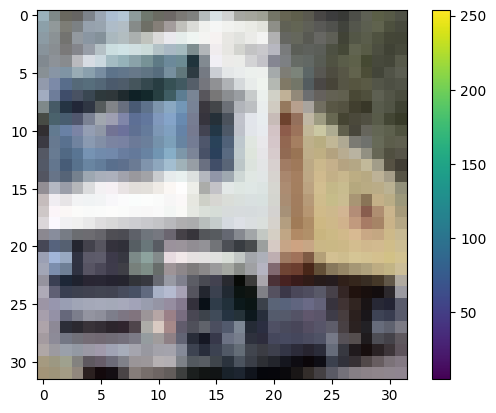

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import *

# CFAR-10 데이터 세트
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

plt.figure()
plt.imshow(X_train[1])
plt.colorbar()

Epoch 1/10
1094/1094 [==============================] - 19s 17ms/step - loss: 1.5328 - accuracy: 0.4485 - val_loss: 1.3212 - val_accuracy: 0.5386
Epoch 2/10
1094/1094 [==============================] - 19s 17ms/step - loss: 1.2139 - accuracy: 0.5694 - val_loss: 1.2440 - val_accuracy: 0.5559
Epoch 3/10
1094/1094 [==============================] - 19s 17ms/step - loss: 1.0607 - accuracy: 0.6253 - val_loss: 1.1657 - val_accuracy: 0.5938
Epoch 4/10
1094/1094 [==============================] - 19s 18ms/step - loss: 0.9470 - accuracy: 0.6671 - val_loss: 1.1148 - val_accuracy: 0.6109
Epoch 5/10
1094/1094 [==============================] - 19s 18ms/step - loss: 0.8504 - accuracy: 0.7007 - val_loss: 1.0691 - val_accuracy: 0.6273
Epoch 6/10
1094/1094 [==============================] - 20s 18ms/step - loss: 0.7628 - accuracy: 0.7347 - val_loss: 1.0133 - val_accuracy: 0.6527
Epoch 7/10
1094/1094 [==============================] - 20s 19ms/step - loss: 0.6746 - accuracy: 0.7657 - val_loss: 1.0670 -

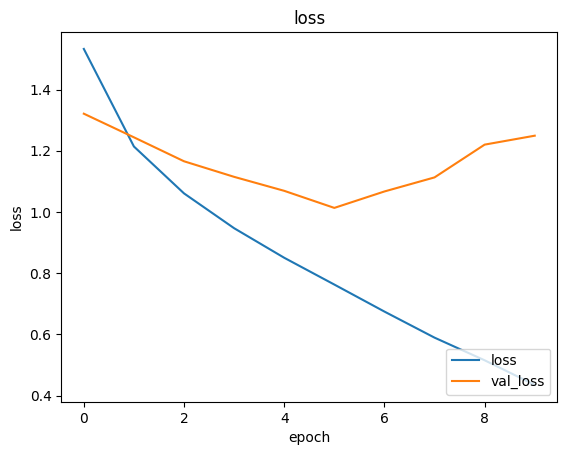

In [13]:
X_train =  X_train/255.0
X_test = X_test/255.0

model = Sequential()
model.add(Conv2D(64, activation='relu', kernel_size=(3,3)))
model.add(MaxPooling2D(pool_size = (2, 2)))
model.add(Conv2D(32, activation='relu', kernel_size=(3,3)))
model.add(Flatten(input_shape=(32, 32, 3)))
model.add(Dense(80, activation='relu'))
model.add(Dense(10, activation='softmax'))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=10, verbose=1, validation_split=0.3)

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['loss', 'val_loss'], loc='lower right')
plt.show()

313/313 [==============================] - 2s 5ms/step
정답 = [[[0.61960784 0.43921569 0.19215686]
  [0.62352941 0.43529412 0.18431373]
  [0.64705882 0.45490196 0.2       ]
  ...
  [0.5372549  0.37254902 0.14117647]
  [0.49411765 0.35686275 0.14117647]
  [0.45490196 0.33333333 0.12941176]]

 [[0.59607843 0.43921569 0.2       ]
  [0.59215686 0.43137255 0.15686275]
  [0.62352941 0.44705882 0.17647059]
  ...
  [0.53333333 0.37254902 0.12156863]
  [0.49019608 0.35686275 0.1254902 ]
  [0.46666667 0.34509804 0.13333333]]

 [[0.59215686 0.43137255 0.18431373]
  [0.59215686 0.42745098 0.12941176]
  [0.61960784 0.43529412 0.14117647]
  ...
  [0.54509804 0.38431373 0.13333333]
  [0.50980392 0.37254902 0.13333333]
  [0.47058824 0.34901961 0.12941176]]

 ...

 [[0.26666667 0.48627451 0.69411765]
  [0.16470588 0.39215686 0.58039216]
  [0.12156863 0.34509804 0.5372549 ]
  ...
  [0.14901961 0.38039216 0.57254902]
  [0.05098039 0.25098039 0.42352941]
  [0.15686275 0.33333333 0.49803922]]

 [[0.23921569 

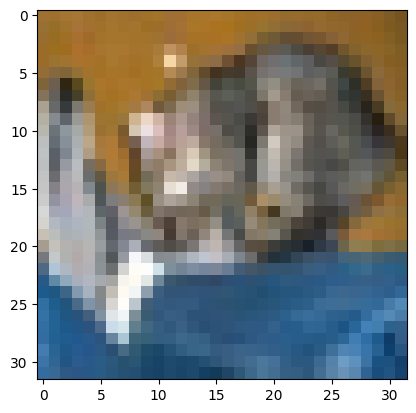

In [9]:
plt.figure()
plt.imshow(X_test[0])
y_pred = model.predict(X_test)
print("정답 =", y_test[0])
print("예측값 =", y_pred[0])